In [22]:
#importing .gz files 
import gzip 
import numpy as np 

#graphite file (check)
filename = 'Gra_81.gz'
print(f"--- Reading headers/comments from {filename} ---")
with gzip.open(filename, 'rt') as f:
    for i in range(15): # Print the first 15 lines
        line = f.readline()
        print(line, end='')

#silicate file (check)
filename = 'Sil_81.gz'
print(f"--- Reading headers/comments from {filename} ---")
with gzip.open(filename, 'rt') as f:
    for i in range(15): # Print the first 15 lines
        line = f.readline()
        print(line, end='')

--- Reading headers/comments from Gra_81.gz ---
Wed Jun  2 11:05:12 EDT 1993
Graphite, 1/3-2/3 approximation, T=25K  
Computed by B.T.Draine (cf Laor, A., & Draine, B.T. 1993, ApJ 402,441)
  81 1.000E-03 1.000E+01 = NRAD, a_1 (micron), a_NRAD (micron)
 241 1.000E+03 1.000E-03 = NWAV, w_1 (micron), w_NWAV (micron)

1.000E-03 = radius(micron) Graphite, 1/3-2/3 approximation, T=25K  
w(micron)  Q_abs     Q_sca     g=<cos>
1.000E+03 2.403E-07 4.131E-21  0.00E+00
9.441E+02 2.674E-07 5.200E-21  0.00E+00
8.913E+02 2.978E-07 6.546E-21  0.00E+00
8.414E+02 3.319E-07 8.240E-21  0.00E+00
7.943E+02 3.701E-07 1.037E-20  0.00E+00
7.499E+02 4.128E-07 1.306E-20  0.00E+00
7.079E+02 4.608E-07 1.644E-20  0.00E+00
--- Reading headers/comments from Sil_81.gz ---
Wed Jun  2 11:05:12 EDT 1993
Astronomical silicate                   
Computed by B.T.Draine (cf Laor, A., & Draine, B.T. 1993, ApJ 402,441)
  81 1.000E-03 1.000E+01 = NRAD, a_1 (micron), a_NRAD (micron)
 241 1.000E+03 1.000E-03 = NWAV, w_1 (micron)

In [23]:
import numpy as np 
import matplotlib.pyplot as plt

In [ ]:
#constants

#bulk densities [g cm^-3] (from Bruce Draine)
rho_gra = 2.24
rho_sil = 3.5 

#physical constants
h = 6.62607015e-24 #Planck [J s]
c = 2.99792458e8 #speed of light [m s^-1]
k_B = 1.380649e-23 #boltzmann [J k^-1]

In [25]:
#func computing BB flux, returns B_lambda in cgs 
def planck_wavelength(micron, T):
    
    #convert microns to cm 1micron=1e-4cm
    cm = micron * 1e-4
    
    #CGS constants 
    h_cgs = 6.62607015e-27 #Planck [erg s]
    c_cgs = 2.99792458e10 #speed of light [cm s^-1]
    k_cgs = 1.380649e-16 #boltzmann [erg k^-1]
    
    exponent = (h_cgs *c_cgs) / (cm * k_cgs * T)
    
    #limit huge results over 500
    exponent = np.clip(exponent, 1e-10, 500)
    
    #planck func for B_lambda in CGS
    b_lam = (2 *h_cgs * c_cgs**2) / (cm**5 * (np.exp(exponent) -1))
    
    return b_lam 

In [ ]:
def parse_bruce_data(filepath):



    with gzip.open(filepath, 'rt') as f:

        lines = f.readlines()

    radii_list = []

    wavelengths = None

    Q_abs_matrix = []

    Q_sca_matrix = []


    i=0

    while i< len(lines):

        line = lines[i].strip()


        #checking if new radius block

        if 'radius(micron)' in line: #scanning for "radius(micron)"

            parts = line.split() #extracting radius value from start of line

            current_radius = float(parts[0]) #grabbing first piece of list, converting to number(grain size)

            radii_list.append(current_radius)


            #skip past the column headers

            i +=4


            block_waves= [] #create empty list for specific grain size

            blocks_qabs = [] #Q abs absorption coefficiency to calc mass absorp coeff kappanu

            blocks_qsca = [] # Q sca scattering efficiency


            #read rows until hit end of text

            while i< len(lines):

                cols = lines[i].split()

                #if line doesn't have at least 4 numerical col, already hit next block

                if len(cols)<4:

                    break

                try:

                    w = float(cols[0])

                    qabs = float(cols[1])

                    qsca = float(cols[2])


                    block_waves.append(w)

                    blocks_qabs.append(qabs)

                    blocks_qsca.append(qsca)

                except ValueError:

                    break

                i +=1



#save wavenelength grid once for every radius block

            if wavelengths is None:

                wavelengths = np.array(block_waves)


            Q_abs_matrix.append(blocks_qabs)

            Q_sca_matrix.append(blocks_qsca)


        else:

            i +=1

    return wavelengths, np.array(radii_list), np.array(Q_abs_matrix), np.array(Q_sca_matrix)



    wavelengths, radii, Q_abs, Q_sca = parse_bruce_data('Sil_81.gz')

    print(f"Radii count: {len(radii)}, Wavelengths count: {len(wavelengths)}")

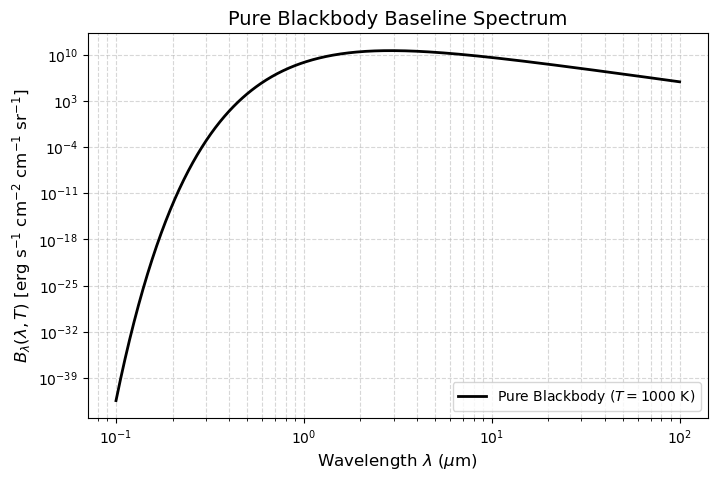

In [26]:
#setting up BB spectrum without dust

micron = np.logspace (-1, 2, 500) #wavelength grid from 0.1 to 10 micron

temperature = 1000 #choosing 1000 K

intensity = planck_wavelength(micron, temperature)

#plot
plt.figure(figsize=(8, 5))
plt.plot(micron, intensity, color='black', lw=2, label=f'Pure Blackbody ($T = {temperature}$ K)')

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'Wavelength $\lambda$ ($\mu$m)', fontsize=12)
plt.ylabel(r'$B_\lambda(\lambda, T)$ [erg s$^{-1}$ cm$^{-2}$ cm$^{-1}$ sr$^{-1}$]', fontsize=12)
plt.title('Pure Blackbody Baseline Spectrum', fontsize=14)
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()